# 重力モデル パラメータ推計デモ

合成データを用いて、交通工学における重力モデルのキャリブレーション手法を検証する。

**推定手法:**
- **Hyman法**: 観測平均トリップコストに一致するようパラメータを逐次更新
- **TLFD法**: 観測トリップ長頻度分布に適合するようパラメータを最適化

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from gravity_model import GravityModel

COLORS = {"red": "#FF4B00", "blue": "#005AFF", "green": "#03AF7A",
          "gray": "#84919E", "black": "#000000"}
mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "IPAexGothic"],
    "font.size": 10, "axes.labelsize": 12, "axes.titlesize": 12,
    "figure.figsize": (3.5, 2.625), "figure.dpi": 150,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "axes.grid": False, "legend.frameon": False,
    "lines.linewidth": 1.5, "lines.markersize": 6,
})

## 1. 合成データの生成

真のパラメータ $\beta=0.08$ の指数型抵抗関数で OD行列を生成し、Poisson ノイズを加えて観測データとする。

In [2]:
np.random.seed(42)
n_zones = 10

O = np.random.randint(200, 1000, n_zones).astype(float)
D = np.random.randint(200, 1000, n_zones).astype(float)
cost = np.random.uniform(5, 40, (n_zones, n_zones))
cost = (cost + cost.T) / 2
np.fill_diagonal(cost, 0)

TRUE_BETA = 0.08
gm = GravityModel(O, D, cost, impedance='exp')
T_true = gm.predict(TRUE_BETA)

# 観測データ (Poisson ノイズ)
T_obs = np.random.poisson(T_true).astype(float)
np.fill_diagonal(T_obs, 0)

# 観測から得られる集計統計量
c_obs = GravityModel.mean_cost_from_od(T_obs, cost)
bins = np.linspace(0, 45, 10)
obs_tlfd = GravityModel.tlfd_from_od(T_obs, cost, bins)

print(f"真のパラメータ: beta = {TRUE_BETA}")
print(f"観測平均トリップコスト: {c_obs:.2f}")
print(f"観測総需要: {T_obs.sum():.0f}")

真のパラメータ: beta = 0.08
観測平均トリップコスト: 17.65
観測総需要: 5352


## 2. Hyman法によるキャリブレーション

入力は **観測平均トリップコスト** のみ。逐次更新で $\beta$ を推定する。

In [3]:
res_hyman = gm.calibrate_hyman(c_obs, verbose=True)
print(f"\n推定 beta = {res_hyman['param']:.4f} (真値: {TRUE_BETA})")
print(f"平均コスト: モデル={res_hyman['mean_cost_model']:.2f}, 観測={c_obs:.2f}")

Iter   0: param=0.056660, c_model=18.4042, c_obs=17.6492, rel_err=0.042780
Iter   1: param=0.059084, c_model=18.3160, c_obs=17.6492, rel_err=0.037781
Iter   2: param=0.061316, c_model=18.2357, c_obs=17.6492, rel_err=0.033234
Iter   3: param=0.063354, c_model=18.1633, c_obs=17.6492, rel_err=0.029130
Iter   4: param=0.065199, c_model=18.0984, c_obs=17.6492, rel_err=0.025452
Iter   5: param=0.066859, c_model=18.0406, c_obs=17.6492, rel_err=0.022176
Iter   6: param=0.068341, c_model=17.9894, c_obs=17.6492, rel_err=0.019275
Iter   7: param=0.069659, c_model=17.9442, c_obs=17.6492, rel_err=0.016717
Iter   8: param=0.070823, c_model=17.9046, c_obs=17.6492, rel_err=0.014472
Iter   9: param=0.071848, c_model=17.8699, c_obs=17.6492, rel_err=0.012508
Iter  10: param=0.072747, c_model=17.8397, c_obs=17.6492, rel_err=0.010795
Iter  11: param=0.073532, c_model=17.8134, c_obs=17.6492, rel_err=0.009306
Iter  12: param=0.074216, c_model=17.7906, c_obs=17.6492, rel_err=0.008013
Iter  13: param=0.074811,

## 3. TLFD法によるキャリブレーション

入力は **観測トリップ長頻度分布 (TLFD)**。カイ二乗統計量を最小化する $\beta$ を探索する。

In [4]:
res_tlfd = gm.calibrate_tlfd(obs_tlfd, bins, method='chi2')
print(f"推定 beta = {res_tlfd['param']:.4f} (真値: {TRUE_BETA})")
print(f"平均コスト: モデル={res_tlfd['mean_cost_model']:.2f}, 観測={c_obs:.2f}")

推定 beta = 0.0779 (真値: 0.08)
平均コスト: モデル=17.67, 観測=17.65


## 4. 結果の可視化

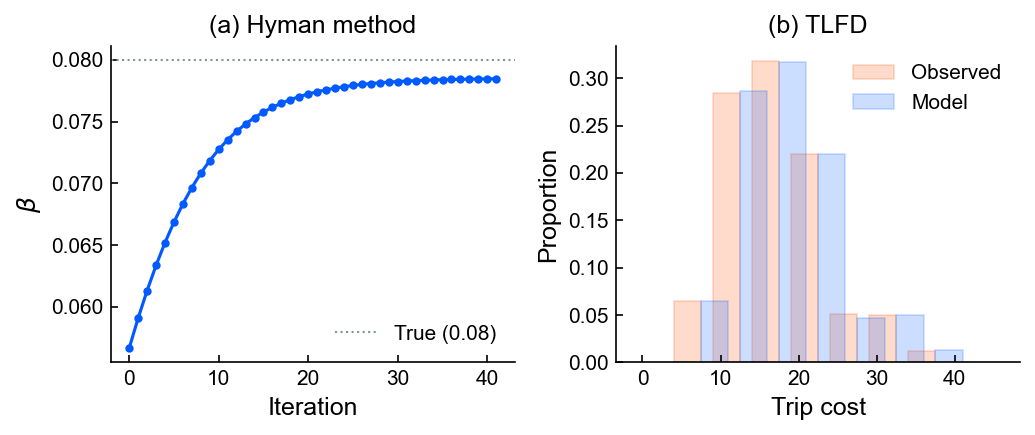

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.0))

# (a) Hyman法の収束過程
ax = axes[0]
iters = [h['iter'] for h in res_hyman['history']]
params = [h['param'] for h in res_hyman['history']]
ax.plot(iters, params, '-o', color=COLORS["blue"], markersize=3)
ax.axhline(y=TRUE_BETA, color=COLORS["gray"], linestyle=':', linewidth=1.0,
           label=f'True ({TRUE_BETA})')
ax.set_xlabel("Iteration")
ax.set_ylabel("$\\beta$")
ax.set_title("(a) Hyman method")
ax.legend(loc='lower right')

# (b) TLFD: 観測 vs モデル
ax = axes[1]
bin_centers = (bins[:-1] + bins[1:]) / 2
obs_norm = obs_tlfd / obs_tlfd.sum()
pred_norm = res_tlfd['predicted_tlfd'] / res_tlfd['predicted_tlfd'].sum()
w = (bins[1] - bins[0]) * 0.35
ax.bar(bin_centers - w, obs_norm, 2*w, color=COLORS["red"], alpha=0.2,
       edgecolor=COLORS["red"], linewidth=0.8, label='Observed')
ax.bar(bin_centers + w, pred_norm, 2*w, color=COLORS["blue"], alpha=0.2,
       edgecolor=COLORS["blue"], linewidth=0.8, label='Model')
ax.set_xlabel("Trip cost")
ax.set_ylabel("Proportion")
ax.set_title("(b) TLFD")
ax.set_ylim(bottom=0)
ax.legend()

plt.tight_layout()
plt.show()